In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y, -y])
x = np.hstack([x, -x])

In [3]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

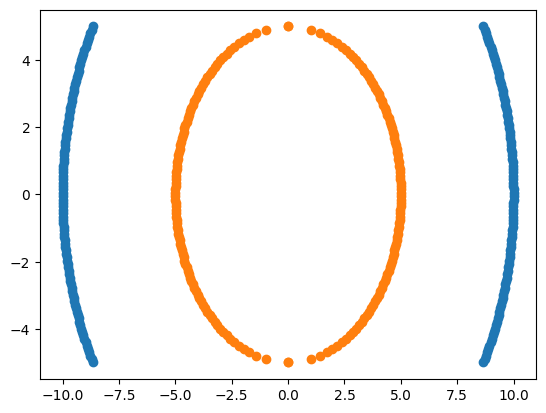

In [4]:
plt.scatter(y, x)
plt.scatter(y1, x1)

In [5]:
df1 = pd.DataFrame(np.vstack([y,x]).T, columns=['X1','X2'])
df1['Y'] = 0
df1

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0
...,...,...,...
195,-8.881281,-4.59596,0
196,-8.828277,-4.69697,0
197,-8.773790,-4.79798,0
198,-8.717792,-4.89899,0


In [6]:
df2 = pd.DataFrame(np.vstack([y1,x1]).T,columns = ['X1','X2'])
df2['Y'] = 1
df2

,X1,X2,Y
0,0.000000,-5.00000,1
1,0.999949,-4.89899,1
2,1.406908,-4.79798,1
3,1.714198,-4.69697,1
4,1.969049,-4.59596,1
...,...,...,...
195,-1.969049,-4.59596,1
196,-1.714198,-4.69697,1
197,-1.406908,-4.79798,1
198,-0.999949,-4.89899,1


In [7]:
df = pd.concat([df1, df2])

In [8]:
df

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0
...,...,...,...
195,-1.969049,-4.59596,1
196,-1.714198,-4.69697,1
197,-1.406908,-4.79798,1
198,-0.999949,-4.89899,1


In [9]:
X = df.iloc[:,:2]
y = df.Y

In [10]:
df['X1*X2'] = df['X1'] * df['X2']

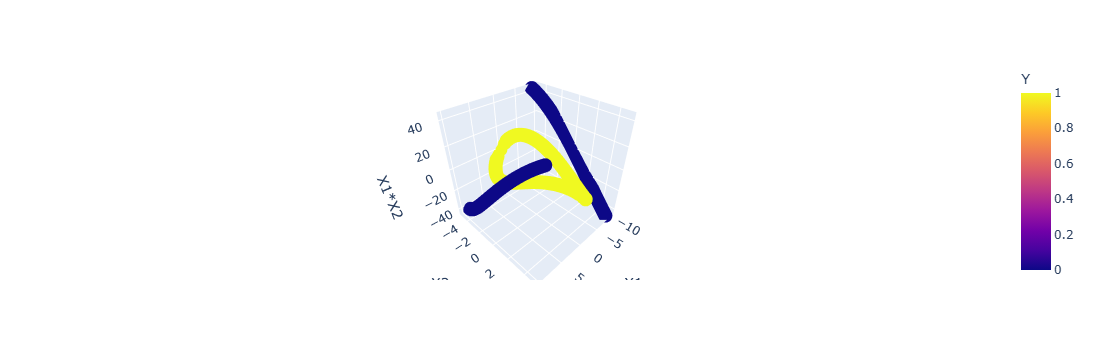

In [11]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2', color='Y')
fig.show()

In [12]:
df

,X1,X2,Y,X1*X2
0,8.660254,-5.00000,0,-43.301270
1,8.717792,-4.89899,0,-42.708375
2,8.773790,-4.79798,0,-42.096467
3,8.828277,-4.69697,0,-41.466150
4,8.881281,-4.59596,0,-40.818009
...,...,...,...,...
195,-1.969049,-4.59596,1,9.049671
196,-1.714198,-4.69697,1,8.051537
197,-1.406908,-4.79798,1,6.750316
198,-0.999949,-4.89899,1,4.898740


### Training of Model

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)

### Using Kernel 'rbf'

In [14]:
from sklearn.svm import SVC
svc = SVC(kernel = 'rbf')
svc.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [15]:
y_pred = svc.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print(accuracy)
print (cm)

1.0
[[52  0]
 [ 0 48]]


### Using kernel 'poly'

In [17]:
svc = SVC(kernel = 'poly')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print(accuracy)
print (cm)

0.69
[[21 31]
 [ 0 48]]


### Using kernel 'sigmoid'

In [18]:
svc = SVC(kernel = 'sigmoid')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print(accuracy)
print (cm)

0.56
[[30 22]
 [22 26]]
